In [1]:
import pandas as pd
import warnings
# from IPython.display import display, HTML
import IPython

import h3
import geopandas
import h3pandas
import numpy as np 
import math
import decimal
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as sm_formula
from shapely import geometry
from scipy import stats

warnings.filterwarnings("ignore")

res = 7

# plt.style.use("ggplot")


In [2]:
def plot_df(df, column=None, ax=None, cmap=None, label=None, title=None, alpha=None, edgecolor=None):
    "Plot based on the `geometry` column of a GeoPandas dataframe"
    df = df.copy()
    df = df.to_crs(epsg=3857)  # web mercator

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    if (title is not None):
        ax.set_title(title)

    # print("cmap", cmap)
    # print(cmap is None)

    if cmap is None:
        legend_kwds = {'loc': 'upper left', 'label': label}
    else:
        legend_kwds = {'shrink': 0.6}

    df.plot(
        ax=ax,
        alpha=alpha, 
        edgecolor=edgecolor,
        column=column, categorical=(cmap is None),cmap=cmap,
        legend=True, legend_kwds=legend_kwds,
    )
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)

# Sewer repair Data Analysis

<!-- image goes here-->



## Target Variable: Sewer Repair alerts

In [3]:
wssc_path = "Datasets/WSSC_Alerts/wssc_alerts_geocoded.shp"
wssc_alerts = geopandas.read_file(wssc_path)
wssc_alerts = wssc_alerts[["title", "date", "pipe_diame", "address", "geometry"]]
# wssc_alerts.rename(columns={"title": "Title", "date": "Date", "pipe_diame": "Pipe Diameter (in)", "address": "Address"}).drop(columns=["geometry"])

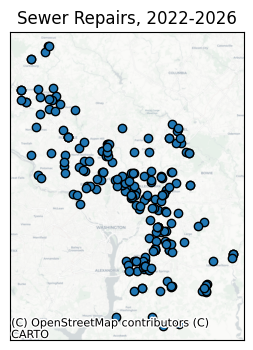

In [4]:
_, ax = plt.subplots(figsize=(4,4))
ax.set_title("Sewer Repairs, 2022-2026")

plot_df(wssc_alerts, ax=ax, edgecolor='k')

Using alerts scraped from the WSSC website


Scraped using [this utility](https://github.com/emmafurth/WSSCAlertsScraper)

In [5]:
# display(wssc_alerts.style.set_sticky(axis=1).hide(subset=["title","geometry"], axis=1).hide().relabel_index(["Date","Pipe Size (in)","Address"], axis=1)) 

In [6]:
wssc_path = "Datasets/WSSC_Alerts/wssc_alerts_geocoded.shp"
wssc_alerts = geopandas.read_file(wssc_path)
wssc_alerts = wssc_alerts[["title", "date", "pipe_diame", "address", "geometry"]]
# wssc_alerts.rename(columns={"title": "Title", "date": "Date", "pipe_diame": "Pipe Diameter (in)", "address": "Address"}).drop(columns=["geometry"])

## Spatial Analysis 

<figure class="embedded-image float-left" style="max-width:50%">
    <img src="images/h3_hexes_v2_cropped.png" />
    <!-- <figcaption>
        <a href="https://h3geo.org/">Source</a>
    </figcaption> -->
</figure>

Will aggregate data into H3 hexes

Advantages:

- Discrete, uniform structure
- Easily indexed with x-y coordinates
- Enables easy joining of disparate spatial datasets

## Aggregating to H3

In [32]:
aggregated_df = wssc_alerts.assign(count=1)[["count","geometry"]].h3.geo_to_h3_aggregate(resolution=res,operation="count").reset_index()
# wssc_alerts_h3_df.head()

base_h3_07_df = geopandas.read_file("EDA/qGIS/h3_07.gpkg").rename(columns={"index": "h3_07"})
wssc_alerts_df = base_h3_07_df.join(aggregated_df.set_index("h3_07").drop(columns=["geometry"]), on="h3_07").fillna({"count": 0}).astype({"count": "int32"})
wssc_alerts_df.head()


,h3_07,geometry,count
0,872aa8516ffffff,"POLYGON ((-77.06863 39.23343, -77.08247 39.226...",0
1,872aa8633ffffff,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",0
2,872aa8426ffffff,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",0
3,872aa80b2ffffff,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",0
4,872aa8449ffffff,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",1


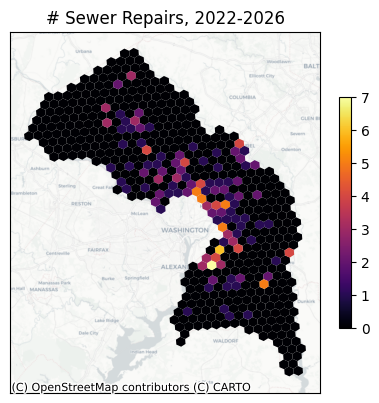

In [8]:
_, ax = plt.subplots( figsize=(5,5))
ax.set_title("# Sewer Repairs, 2022-2026")

plot_df(wssc_alerts_df, column="count", ax=ax, cmap="inferno")


Lorem ipsum dolor sit amet, consectetur adipiscing elit.

Morbi volutpat nisl sit amet consectetur blandit.

Aenean nec mauris ac lectus mattis consectetur.


In [9]:
# display(wssc_alerts_df.style.set_sticky(axis=1).hide(subset=["title","geometry"], axis=1).hide().relabel_index(["Date","Pipe Size (in)","Address"], axis=1)) 
# display(wssc_alerts_df.style.set_sticky(axis=1).hide(subset=["geometry"], axis=1).hide())

## Global Spatial Autocorrelation

<figure class="no-margin no-padding img-with-cite" style="width:60%;">
    <img src="images/moransi_stat-7B209.gif" />
    <figcaption>
        (<a href="https://doc.esri.com/en/arcgis-pro/latest/tool-reference/spatial-statistics/spatial-autocorrelation.html?tabs=dialog">Source</a>)
    </figcaption>
</figure>

Does the data cluster, or disperse?

<p class="fragment">Z-score: How much the variable in a given hex deviates from the mean</p>

<p class="fragment">Spatial Lag: The average value of each hex and all its neighbors </p>

<p class="fragment">Global Moran's I:</p>

In [ ]:
wssc_path = "Datasets/WSSC_Alerts/wssc_alerts_geocoded.shp"
wssc_alerts = geopandas.read_file(wssc_path)
wssc_alerts = wssc_alerts[["title", "date", "pipe_diame", "address", "geometry"]]
# wssc_alerts.rename(columns={"title": "Title", "date": "Date", "pipe_diame": "Pipe Diameter (in)", "address": "Address"}).drop(columns=["geometry"])

In [10]:
def prepare_geodataframe_GMI(df_aggreg, target_col = "count", num_rings = 2, 
                             flag_debug = False, flag_return_gdf = True):
    """Prepares dataframe for Global Moran's I computation, namely by
       computing z-score and geometry object for each row of the input df_aggreg"""

    df_aux = df_aggreg.copy()

    # get resolution from the hex_id of the first row (assume all the same in df_aggreg)
    # res = h3.get_resolution(df_aux.iloc[0]["h3_07"])
    res = 7
    mean_count_cell = df_aux[target_col].mean()
    stddev_count_cell = df_aux[target_col].std(ddof = 0)

    if flag_debug is True:
        msg_ = "Average number of count per H3 cell at resolution {} : {}"
        print(msg_.format(res, mean_count_cell))

    # z_score column
    df_aux["z_score"] = (df_aux[target_col] - mean_count_cell) / stddev_count_cell

    # list of cell ids on hollow rings
    for i in range(1, num_rings + 1):
        df_aux["ring{}".format(i)] = df_aux["h3_07"].apply(lambda x:
                                                            list(h3.grid_ring(h = x,
                                                                             k = i)))

    if flag_return_gdf is True:
        # make shapely geometry objects out of geojson
        df_aux["geometry_shp"] = df_aux["geometry"].apply(
                                              lambda x:
                                              geometry.Polygon(geometry.shape(x)))
        df_aux.rename(columns={"geometry": "geometry_geojson"}, inplace=True)

        geom = df_aux["geometry_shp"]
        df_aux.drop(columns=["geometry_shp"], inplace = True)
        gdf_aux = geopandas.GeoDataFrame(df_aux, crs="EPSG:4326", geometry=geom)

        return gdf_aux
    else:
        
        return df_aux
def compute_spatial_lags_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes spatial lags for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    gdf_aux = gdf_prepared.copy()
    gdf_aux["spatial_lag"] = np.nan

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value    

            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            # spatial lag
            spatial_lag = wij_adjusted * sum_neighbors

            gdf_aux.loc[gdf_aux["h3_07"] == hex_id, "spatial_lag"] = spatial_lag

    return gdf_aux

In [11]:
alert_prepared_GMI_df = prepare_geodataframe_GMI(wssc_alerts_df, num_rings = 1)
alert_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "count")

# alert_prepared_GMI_df.head()
# alert_spatial_lags_df.head()


### Global Moran's I

In [12]:
def compute_Global_Moran_I_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes Global Moran I for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    S_wijzizj = 0
    S_wij = gdf_prepared.shape[0]

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # now, in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        zi = dict_z[hex_id]
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value
            
            # update sum
            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            S_wijzizj += wij_adjusted * zi * sum_neighbors

    GMI = S_wijzizj / S_wij
    return GMI

def reshuffle_and_recompute_GMI(gdf_prepared, variable_col = "z_score",
                                num_permut = 999, I_observed = None,
                                alpha = 0.005, alternative = "greater",
                                flag_plot = True, flag_verdict = True):
    """Permutation inference with number of permutations given by num_permut and
       pseudo significance level specified by alpha"""

    gdf_aggreg_reshuff = gdf_prepared.copy()
    list_reshuff_I = []

    for i in range(num_permut):
        # simulate by reshuffling column
        gdf_aggreg_reshuff[variable_col] = np.random.permutation(
                                             gdf_aggreg_reshuff[variable_col].values)

        I_reshuff = compute_Global_Moran_I_using_H3(gdf_prepared = gdf_aggreg_reshuff)
        list_reshuff_I.append(I_reshuff)

    # for hypothesis testing
    list_reshuff_I.append(I_observed)

    # empirical CDF
    ecdf_GMI = sm.distributions.empirical_distribution.ECDF(list_reshuff_I, side = "left")

    percentile_observedI = stats.percentileofscore(list_reshuff_I,
                                                   I_observed,
                                                   kind='strict')
    # note: use decimal to avoid 99.9 / 100 = 0.9990000000000001
    percentile_observedI_ = float(str(decimal.Decimal(str(percentile_observedI)) / 100))

    try:
        assert(ecdf_GMI(I_observed) == percentile_observedI_)
    except Exception:
        pass
        # print(ecdf_GMI(I_observed), " vs ", percentile_observedI_)

    msg_reject_H0 = "P_sim = {:3f} , we can reject H0"
    msg_failtoreject_H0 = "P_sim = {:3f} , we fail to reject H0 under alternative {}"
        
    if alternative == "greater":
        pseudo_p_value = 1 - ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "less":
        pseudo_p_value = ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "two-tailed":
        pseudo_p_value_greater = 1 - ecdf_GMI(I_observed)
        pseudo_p_value_less = ecdf_GMI(I_observed)
        pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
        
        if flag_verdict is True:
            if (pseudo_p_value_greater < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_greater))
            elif (pseudo_p_value_less < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_less))
            else:
                pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
        
    return (pseudo_p_value, list_reshuff_I)


In [13]:
gmi_results = compute_Global_Moran_I_using_H3(gdf_prepared = alert_prepared_GMI_df)
print("I =", gmi_results)

I = 0.2729805843255545


In [14]:
p_sim, list_reshuff_I = reshuffle_and_recompute_GMI(gdf_prepared = alert_prepared_GMI_df,   
                                    num_permut = 999,                            
                                    I_observed = gmi_results,
                                    alternative = "two-tailed",
                                    flag_plot = True)

P_sim = 0.001000 , we can reject H0


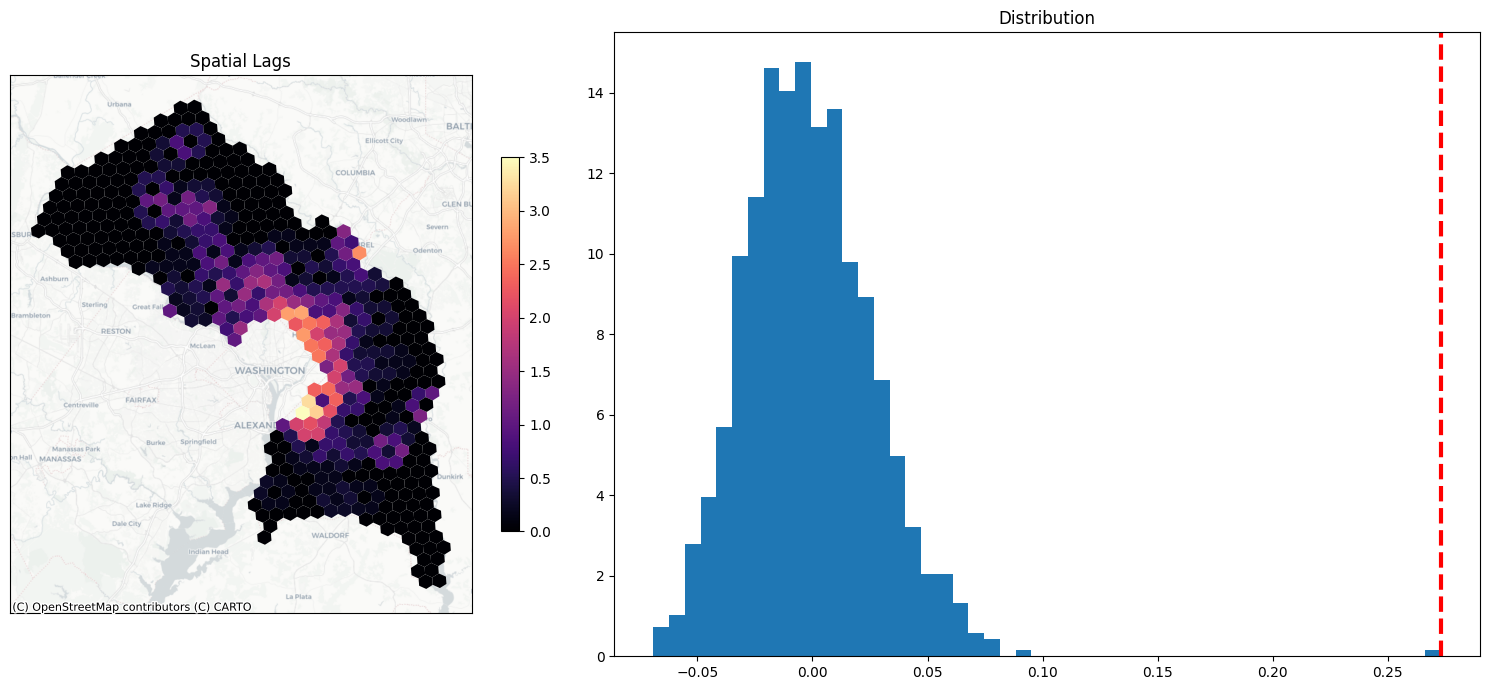

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7),
                        gridspec_kw={'width_ratios': [2, 3]})
ax[0].set_title("Spatial Lags")
ax[1].set_title("Distribution")

# alert_prepared_GMI_df.plot(column="count", cmap= "viridis", ax=ax[0], legend=False)
plot_df(alert_spatial_lags_df, column="spatial_lag", ax=ax[0], cmap="magma")

ax[1].hist(list_reshuff_I, density=True, bins=50)
ax[1].axvline(gmi_results, color = 'red', linestyle = '--', linewidth = 3)
fig.tight_layout()

Spatial lags also make for smoother, prettier graphics

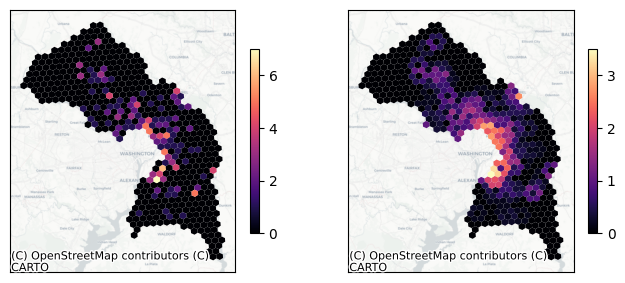

In [16]:
_, axs = plt.subplots(ncols=2,figsize=(8,4))
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)
# axs[0].set_title("Pre Smoothing")
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
# axs[1].set_title("Post Smoothing")

plot_df(wssc_alerts_df, column="count", ax=axs[0], cmap="magma")
# plot_df(alert_spatial_lags_df, column="spatial_lag", ax=axs[0], cmap="magma")
plot_df(alert_spatial_lags_df, column="spatial_lag", ax=axs[1], cmap="magma")

## Data Analysis with Other Variables

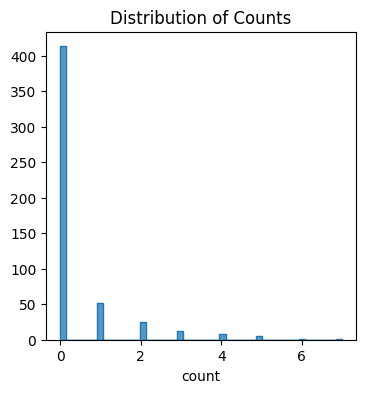

In [17]:
_, ax = plt.subplots(figsize=(4,4))
sns.histplot(x=wssc_alerts_df["count"], element="step", ax=ax, legend=None)
ax.set_title("Distribution of Counts")
ax.set_ylabel(None)
# ax.grid(visible=True, axis="y")
plt.show()


Distribution of the counts looks like Poisson regression

Need to find other spatial variables to correlate

### Independent Variable 1: Traffic

In [18]:
traffic_path = "Datasets/MDOT_SHA_Annual_Average_Daily_Traffic_locations/MDOT_SHA_Annual_Average_Daily_Traffic_(AADT)_Locations.shp"
traffic_df = geopandas.read_file(traffic_path)
traffic_df = traffic_df[(traffic_df["COUNTY_DES"] == "MONTGOMERY") | (traffic_df["COUNTY_DES"] == "PRINCE GEORGE'S")]
traffic_df = traffic_df.to_crs("EPSG:4326")
traffic_df = traffic_df.astype({"AADT_2023":"int64"})
# traffic_df = traffic_df[["ROADNAME", "AADT_2023", "AAWDT_2023", "geometry"]] #.rename(columns={"ROADNAME":"Road Name", "AADT_2023":"Annual Avg Daily Traffic (2023)"})
# traffic_df.head()



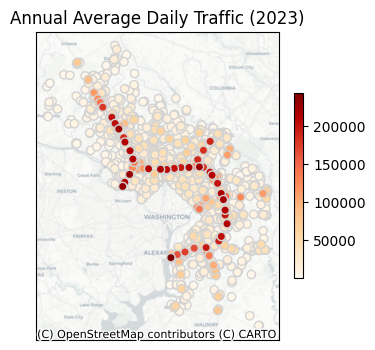

In [19]:
_, ax = plt.subplots(figsize=(4,4))
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_title("Annual Average Daily Traffic (2023)")

# test = traffic_df.copy()
# test = test.to_crs(epsg=3857)

legend_kwds = {'shrink': 0.6 }

traffic_df.sort_values(by="AADT_2023").plot(
    ax=ax,
    # alpha=0.5,
    edgecolor='lightgray',
    column="AADT_2023", categorical=False, cmap="OrRd",
    legend=True, legend_kwds=legend_kwds
)
cx.add_basemap(ax, crs=traffic_df.crs, source=cx.providers.CartoDB.Positron)

Annual Average Daily Traffic (AADT) 
    
The number of vehicles expected to pass a given location on an average day of the year ([Source](https://www.roads.maryland.gov/OPPEN/Data_Dictionary.pdf))

Source: Maryland Department of Transportation (MDOT)

Reasoning: High traffic -> More underground vibrartions -> potential damage to sewer pipes

In [20]:
# display(traffic_df[["LOCATION_I", "AADT_2023", "STATION_DE"]].style.set_sticky(axis=1).hide().relabel_index(["Location ID","AADT (2023)", "Station"], axis=1))

### Independent Variable 2: Tree Canopy 

In [21]:

canopy_df = geopandas.read_file("Datasets/Tree_canopy_2023_Merged.gdb")
canopy_df.head()

,COUNT,FEATURE_CODE,SOURCE_CODE,Shape_Length,Shape_Area,geometry
0,54958.0,NaN,NaN,419.462245,6111.840381,"MULTIPOLYGON (((1236734.096 514232.727, 123688..."
1,54958.0,NaN,NaN,14.053587,1.291159,"MULTIPOLYGON (((1240402.766 507935.321, 124039..."
2,54958.0,NaN,NaN,9.090781,1.440954,"MULTIPOLYGON (((1240422 507938, 1240419.096 50..."
3,54958.0,NaN,NaN,579.424768,14608.294419,"MULTIPOLYGON (((1237405.096 515182.727, 123741..."
4,54958.0,NaN,NaN,395.094711,8058.817236,"MULTIPOLYGON (((1239935.594 523980.593, 123996..."


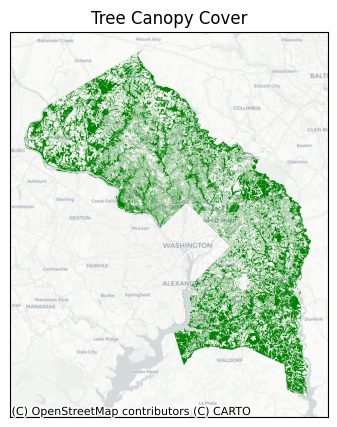

In [22]:
_, ax = plt.subplots(figsize=(5,5))
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_title("Tree Canopy Cover")

# print("cmap", cmap)
# print(cmap is None)

legend_kwds = {'shrink': 0.6 }

canopy_df.plot(
    ax=ax,
    # alpha=0.5,
    # edgecolor='white',
    color="green",
    legend=True, legend_kwds=legend_kwds
)
cx.add_basemap(ax, crs=canopy_df.crs, source=cx.providers.CartoDB.Positron)

- Tree Canopy

<!-- TODO: Insert info about data source -->

### Aggregating to H3 Hexagons

In [23]:
# traffic_h3_df = traffic_df.h3.geo_to_h3_aggregate(res, operation='sum').reset_index()
# traffic_h3_df.head()


# # # traffic_h3_df.columns = traffic_h3_df.columns.map('_'.join)
# # traffic_h3_df = traffic_h3_df.h3.h3_to_geo_boundary()
# # traffic_h3_df.head()

aggregated_traffic_df = traffic_df.h3.geo_to_h3_aggregate(res,operation={'AADT_2023': 'sum'}, return_geometry=False) #.reset_index()
# aggregated_traffic_df.columns = aggregated_traffic_df.columns.map('_'.join)
aggregated_traffic_df = aggregated_traffic_df.h3.h3_to_geo_boundary().reset_index()

traffic_h3_df = base_h3_07_df.join(aggregated_traffic_df.set_index("h3_07").drop(columns=["geometry"]), on="h3_07").fillna({"AADT_2023": 0}).astype({"AADT_2023": "int64"})
traffic_h3_df.head()

,h3_07,geometry,AADT_2023
0,872aa8516ffffff,"POLYGON ((-77.06863 39.23343, -77.08247 39.226...",0
1,872aa8633ffffff,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",2845
2,872aa8426ffffff,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",20909
3,872aa80b2ffffff,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1880
4,872aa8449ffffff,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",74807


In [24]:
canopy_h3_df = geopandas.read_file("EDA/qGIS/h3_07_tree_canopy_overlap.gpkg")
canopy_h3_df = canopy_h3_df.rename(columns={"index":"h3_07"}).drop(columns=["canopy_area"])
canopy_h3_df.head()

,h3_07,canopy_pct,geometry
0,872aa8516ffffff,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226..."
1,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724..."
2,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119..."
3,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004..."
4,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871..."


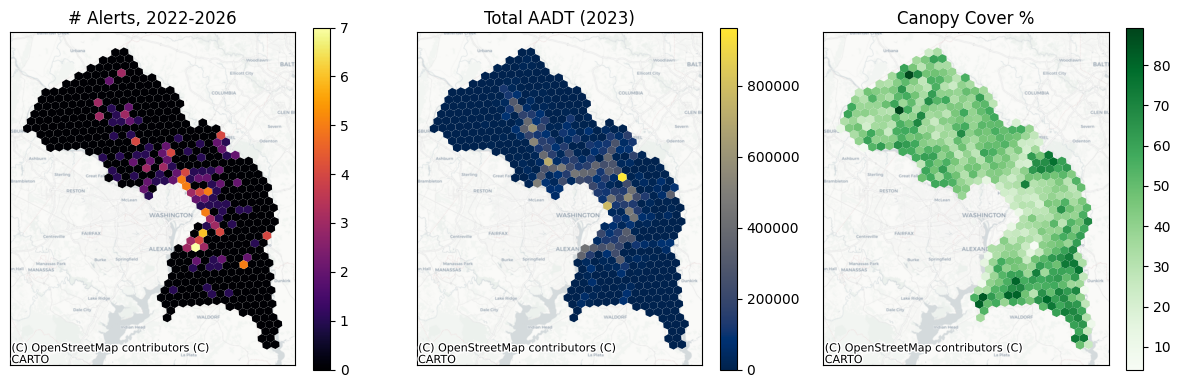

In [25]:
# dfs = [traffic_h3_df, canopy_h3_df]
# cols=["count", "AADT_2023_sum", "canopy_pct"]
# # cmaps = ["inferno","inferno","Greens"]
# plot_df_side_by_side(dfs=dfs,columns=cols, cmap="inferno")

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].set_title("# Alerts, 2022-2026")
ax[1].set_title("Total AADT (2023)")
ax[2].set_title("Canopy Cover %")

# alert_prepared_GMI_df.plot(column="count", cmap= "viridis", ax=ax[0], legend=False)
plot_df(wssc_alerts_df,column="count", ax=ax[0], cmap="inferno")
plot_df(traffic_h3_df, column="AADT_2023", ax=ax[1], cmap="cividis")
plot_df(canopy_h3_df, column="canopy_pct", ax=ax[2], cmap="Greens")
fig.tight_layout()

In [26]:
joined_df = canopy_h3_df.set_index("h3_07").join(
    traffic_h3_df.set_index("h3_07").drop(columns=["geometry"]), 
    on="h3_07"
    ).join(
        wssc_alerts_df.set_index("h3_07").drop(columns=["geometry"]), on="h3_07").reset_index()
joined_df = joined_df.fillna(0)

joined_df.head()



,h3_07,canopy_pct,geometry,AADT_2023,count
0,872aa8516ffffff,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226...",0,0
1,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",2845,0
2,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",20909,0
3,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1880,0
4,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",74807,1


### Pair Plot

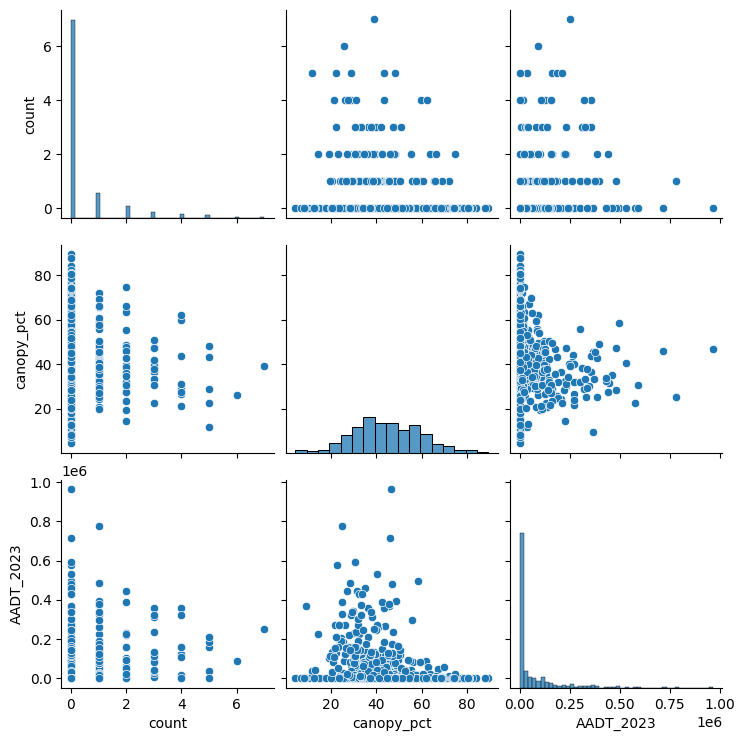

In [27]:
cols = ["count", "canopy_pct", "AADT_2023"]
sns.pairplot(joined_df[cols])
plt.show()

### Poisson Regression

- H0: No correlation between canopy and traffic vs alerts

- H1: There is some correlation

- Significane level: 0.05

In [28]:
# Linear regression
X = joined_df[["canopy_pct", "AADT_2023"]]
y = joined_df["count"]



In [29]:
print("Mean: ", np.var(y))
print("Variance: ", np.var(y))

Mean:  0.994810860155113
Variance:  0.994810860155113


### Results

In [30]:
poisson_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Poisson())
poisson_result = poisson_model.fit()
display(poisson_result.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  count   No. Observations:                  517
Model:                            GLM   Df Residuals:                      514
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -460.45
Date:                Wed, 13 May 2026   Deviance:                       664.67
Time:                        17:26:12   Pearson chi2:                 1.12e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1441
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0673      0.224      0.300      0.764      -0.372       0.507
canopy_pct    -0.0289      0.005     -5.507      0.000      -0.039      -0.019
AADT_2023   2.271e-06   3.59e-07      6.330      0.000    1.57e-06    2.97e-06
==============================================================================
"""

p is less than 0.05 for both variables

We can reject H0

However, pseudo R-squared is rather low

## Conclusion

Statistically significant evidence for Spatial Autocorrelation

Same for correlation with traffic & tree canopy

Relationships are weak

More research needed